Autor: Estéfano Galarza

Tema tesis: Predicción temprana de estres usando datos fisiológicos multimodales

Proyecto: Prediccion sobre actividad usando datos fisiológicos. Introduccion/motivacion, EDA, Feature Extraction, Feature Selection, Optimización de hiperparametros, Comparación estadística de técnicas ML (Random Forest, transformers)

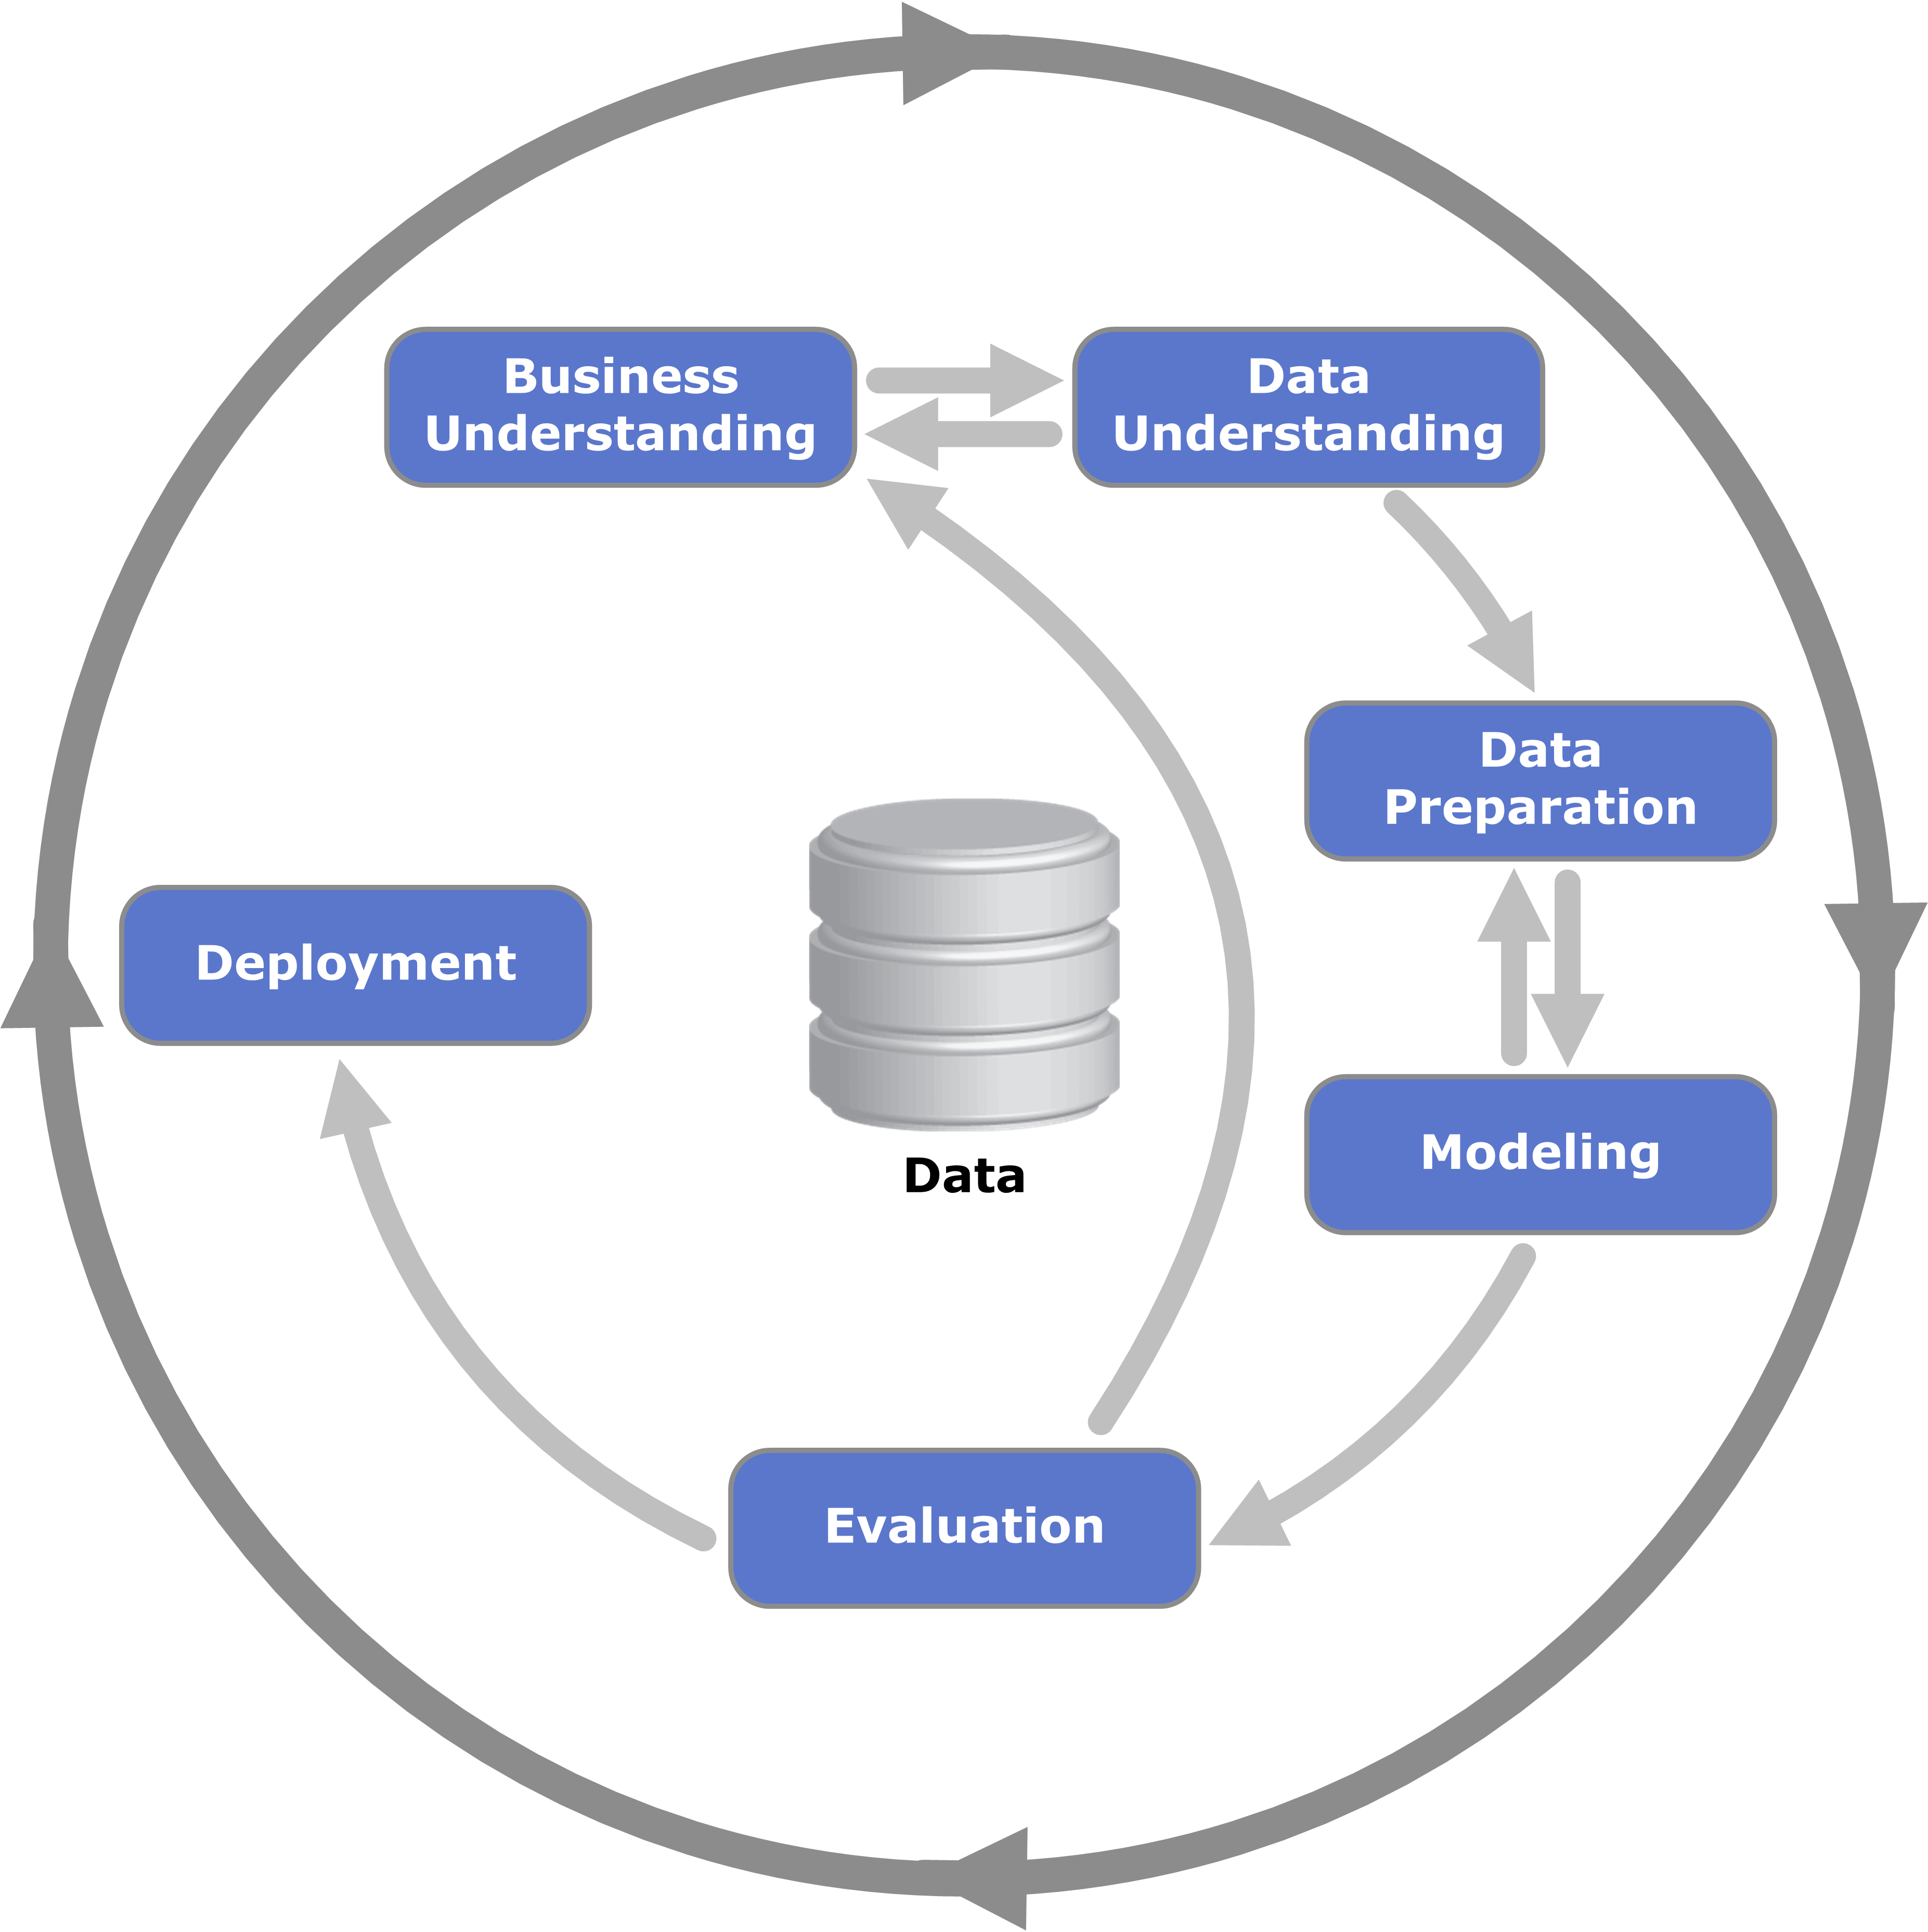

## 1. Business Understanding

Problema: Los trastornos de ansiedad son problemas de salud mental globales, pero los métodos tradicionales de detección (como los cuestionarios de autoreporte) tienen limitaciones al no ser dinámicos ni cuantitativos

La Solución Tecnológica: El uso de tecnología wearable permite el monitoreo en tiempo real de la respuesta del sistema nervioso autónomo mediante señales como la actividad electrodérmica (EDA), el volumen de pulso sanguíneo (BVP) y la electrocardiografía (ECG).

Objetivo: Evaluar la resiliencia al ruido ambiental en la clasificación de estados de ansiedad, estableciendo un modelo base robusto mediante Random Forest para posteriormente contrastarlo con arquitecturas avanzadas de Transformers, cuantificando el rendimiento y la degradación de los modelos al inyectar niveles controlados de ruido gaussiano sintético en el dataset WESAD preprocesado (may14_feats4.csv) mediante métricas como F1-Score, Curva ROC, AUC y Accuracy, y validando los resultados con K-Fold Cross-Validation para evitar sobreajuste; este análisis, desarrollado con librerías estándar de Python y posteriormente escalado a frameworks de Deep Learning, permitirá determinar qué paradigma algorítmico mantiene mejor su capacidad discriminativa en entornos ruidosos para el desarrollo de sistemas wearables de detección de ansiedad viables en el mundo real, completando el modelado, la validación cruzada y la evaluación inicial con Random Forest durante el primer avance del proyecto, y dejando la implementación y comparación con Transformers para la fase final.

## 2. Data understanding/EDA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [5]:
pd.reset_option('display.max_rows'); pd.reset_option('display.max_columns')

In [6]:
#Carga de data
df = pd.read_csv("../anxietyFB-main/data/may14_feats4.csv")
df

,Unnamed: 0,net_acc_C_mean,net_acc_C_std,net_acc_C_min,net_acc_C_max,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,EDA_mean,...,Resp_C_Inhal_std,Resp_C_Exhal_mean,Resp_C_Exhal_std,Resp_C_I/E,TEMP_drange,TEMP_C_drange,TEMP_slope,TEMP_C_slope,subject,label
0,0,0.000531,0.000086,0.000371,0.000788,0.025961,0.013811,0.000000,0.087383,1.303625,...,0.622539,1.839898,0.741267,1.113083,1.003357,1.014887,-0.000253,-1.377799e-06,2,1
1,1,0.000426,0.000004,0.000400,0.000443,0.027640,0.010597,0.002752,0.054356,0.892549,...,0.189863,1.487778,0.439986,1.003521,1.002524,1.016588,-0.000161,-6.099829e-06,2,1
2,2,0.000427,0.000004,0.000407,0.000444,0.028389,0.006937,0.000000,0.066053,0.598712,...,0.345404,1.431053,0.437193,0.927337,1.003640,1.010799,0.000535,1.041127e-06,2,1
3,3,0.000460,0.000050,0.000397,0.000643,0.033268,0.007670,0.000000,0.074998,0.504760,...,0.252339,1.567381,0.678817,0.942731,1.003355,1.015345,-0.000256,-3.158520e-06,2,1
4,4,0.000441,0.000003,0.000427,0.000458,0.037021,0.001284,0.027522,0.043347,0.456286,...,0.138846,1.338357,0.116270,1.007579,1.001957,1.015297,0.000260,-4.752758e-06,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,572,0.000608,0.000018,0.000519,0.000721,0.029596,0.007250,0.002064,0.070870,1.019429,...,0.925958,2.198571,0.806926,0.969352,1.003035,1.009289,-0.000225,-1.991283e-06,17,0
573,573,0.000608,0.000004,0.000593,0.000625,0.030401,0.000552,0.028898,0.031650,1.015634,...,0.449312,1.729810,0.163246,0.999835,1.002431,1.007332,-0.000249,2.515800e-07,17,0
574,574,0.000607,0.000006,0.000536,0.000678,0.029762,0.000721,0.026834,0.035779,1.012849,...,0.561151,1.982527,0.814294,1.034089,1.002741,1.006967,-0.000174,-2.817866e-07,17,0
575,575,0.000603,0.000009,0.000512,0.000682,0.033337,0.001668,0.028898,0.041283,1.005232,...,0.203108,1.604202,0.174612,0.931954,1.001217,1.007922,0.000068,-1.085821e-06,17,0


In [7]:
df = df.drop(columns=["Unnamed: 0"])
df

,net_acc_C_mean,net_acc_C_std,net_acc_C_min,net_acc_C_max,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,EDA_mean,EDA_std,...,Resp_C_Inhal_std,Resp_C_Exhal_mean,Resp_C_Exhal_std,Resp_C_I/E,TEMP_drange,TEMP_C_drange,TEMP_slope,TEMP_C_slope,subject,label
0,0.000531,0.000086,0.000371,0.000788,0.025961,0.013811,0.000000,0.087383,1.303625,0.151736,...,0.622539,1.839898,0.741267,1.113083,1.003357,1.014887,-0.000253,-1.377799e-06,2,1
1,0.000426,0.000004,0.000400,0.000443,0.027640,0.010597,0.002752,0.054356,0.892549,0.142093,...,0.189863,1.487778,0.439986,1.003521,1.002524,1.016588,-0.000161,-6.099829e-06,2,1
2,0.000427,0.000004,0.000407,0.000444,0.028389,0.006937,0.000000,0.066053,0.598712,0.066870,...,0.345404,1.431053,0.437193,0.927337,1.003640,1.010799,0.000535,1.041127e-06,2,1
3,0.000460,0.000050,0.000397,0.000643,0.033268,0.007670,0.000000,0.074998,0.504760,0.018053,...,0.252339,1.567381,0.678817,0.942731,1.003355,1.015345,-0.000256,-3.158520e-06,2,1
4,0.000441,0.000003,0.000427,0.000458,0.037021,0.001284,0.027522,0.043347,0.456286,0.036839,...,0.138846,1.338357,0.116270,1.007579,1.001957,1.015297,0.000260,-4.752758e-06,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,0.000608,0.000018,0.000519,0.000721,0.029596,0.007250,0.002064,0.070870,1.019429,0.007279,...,0.925958,2.198571,0.806926,0.969352,1.003035,1.009289,-0.000225,-1.991283e-06,17,0
573,0.000608,0.000004,0.000593,0.000625,0.030401,0.000552,0.028898,0.031650,1.015634,0.001740,...,0.449312,1.729810,0.163246,0.999835,1.002431,1.007332,-0.000249,2.515800e-07,17,0
574,0.000607,0.000006,0.000536,0.000678,0.029762,0.000721,0.026834,0.035779,1.012849,0.002051,...,0.561151,1.982527,0.814294,1.034089,1.002741,1.006967,-0.000174,-2.817866e-07,17,0
575,0.000603,0.000009,0.000512,0.000682,0.033337,0.001668,0.028898,0.041283,1.005232,0.003284,...,0.203108,1.604202,0.174612,0.931954,1.001217,1.007922,0.000068,-1.085821e-06,17,0


In [8]:
df.shape

(577, 120)

In [9]:
df.isnull().sum()

net_acc_C_mean    0
net_acc_C_std     0
net_acc_C_min     0
net_acc_C_max     0
net_acc_mean      0
                 ..
TEMP_C_drange     0
TEMP_slope        0
TEMP_C_slope      0
subject           0
label             0
Length: 120, dtype: int64

In [10]:
df.isnull().sum().sum() #Al no poder ver todas las columnas

np.int64(0)

In [11]:
df['label'].value_counts(normalize=True) * 100

label
1    54.072790
2    30.329289
0    15.597920
Name: proportion, dtype: float64

C:\Users\estef\AppData\Local\Temp\ipykernel_9392\2510921168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette='viridis')


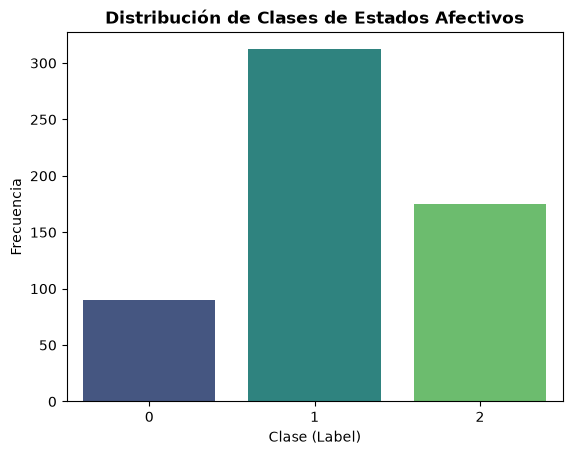

In [12]:
# Visualización del Desbalanceo de Clases
plt.figure()
ax = sns.countplot(data=df, x='label', palette='viridis')
plt.title("Distribución de Clases de Estados Afectivos", fontweight='bold')
plt.xlabel("Clase (Label)")
plt.ylabel("Frecuencia")
plt.show()

In [13]:
# # Análisis de Características Clave 
# # El paper indica que EDA_SCL_max y BVP/ECG son biomarcadores top.
# top_features = ['EDA_SCL_max', 'ECG_bpm', 'ECG_std', 'TEMP_mean', 'accZ_std']
# # Extraer solo las que existen en el dataset actual
# existing_top_features = [feat for feat in top_features if feat in df.columns]

In [14]:
correlations = df.corr()
correlations["label"].sort_values(ascending=False)


label           1.000000
EDA_SCL_max     0.647831
EDA_SCL_mean    0.641174
EDA_SCL_min     0.629194
ECG_bpm         0.548184
                  ...   
ECG_min        -0.304055
ECG_pnn20      -0.321408
EDA_SCR_min    -0.425529
Resp_C_rate    -0.526967
ECG_ibi        -0.529081
Name: label, Length: 120, dtype: float64

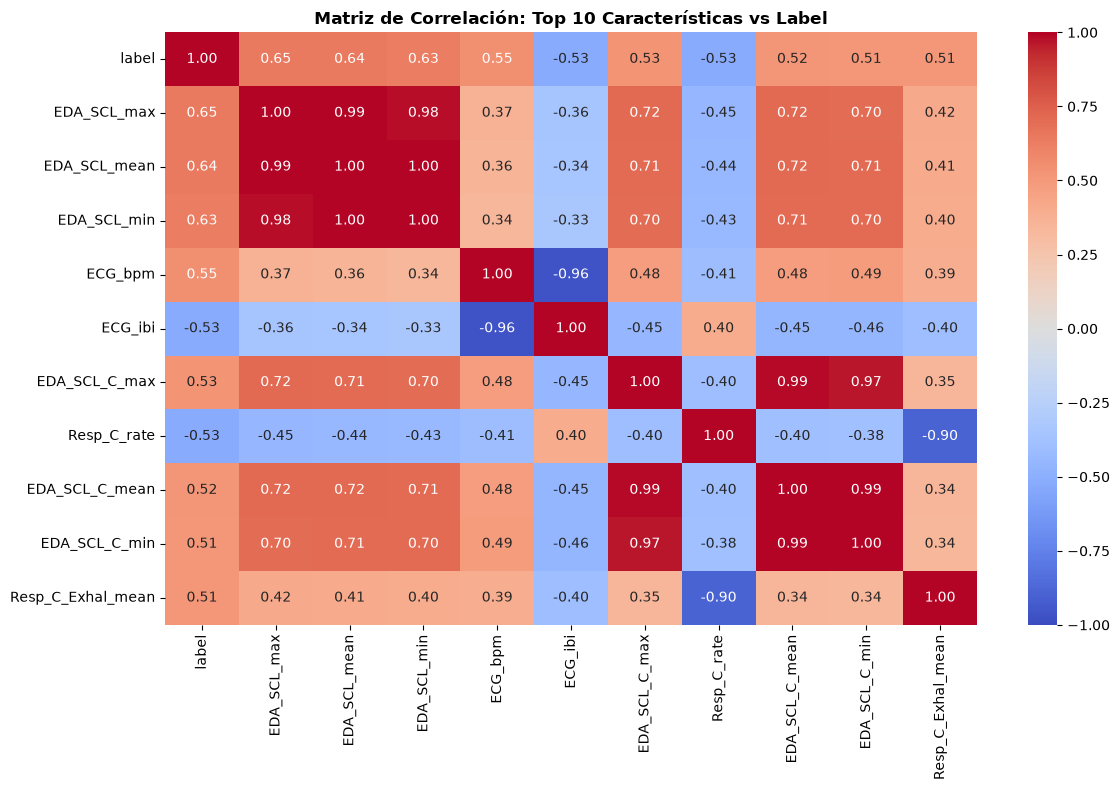

In [15]:
top_10_corr_vars = df.corr()['label'].abs().sort_values(ascending=False).head(11).index
df_top_10 = df[top_10_corr_vars]

plt.figure(figsize=(12, 8))
sns.heatmap(df_top_10.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación: Top 10 Características vs Label", fontweight='bold')
plt.tight_layout()
plt.show()

**Calidad Estructural e Integridad**: El conjunto de datos presenta una integridad del 100%. Tras eliminar el índice residual (Unnamed: 0), la matriz de datos consta de 577 instancias y 120 variables predictoras. La validación de valores nulos (df.isnull().sum().sum()) confirmó la ausencia total de datos faltantes, lo que exime al proyecto de aplicar técnicas de imputación complejas y garantiza que las métricas extraídas de los sensores son continuas y completas.

**Desbalanceo de Clases**: El análisis de la distribución porcentual de la variable objetivo (label) y su respectivo gráfico de conteo revelan un desbalanceo en las clases de los estados afectivos. Este hallazgo empírico justifica plenamente la decisión metodológica de utilizar métricas de evaluación robustas para clases desbalanceadas, tales como el F1-Score, Curva ROC y AUC, y la necesidad de aplicar Stratified K-Fold Cross Validation en las siguientes etapas.

**Poder Predictivo y Multicolinealidad**: La extracción de las correlaciones absolutas contra la variable label y su posterior visualización en el mapa de calor (Top 10) validan lo establecido en la revisión de la literatura. Biomarcadores específicos del sistema nervioso autónomo (como la actividad electrodérmica máxima y métricas cardíacas) presentan la mayor correlación con la etiqueta de ansiedad. Asimismo, el mapa de calor revela la presencia de multicolinealidad entre algunas características derivadas de la misma señal, lo que sugiere que algoritmos de ensamble como Random Forest serán ideales por su capacidad intrínseca para manejar variables correlacionadas sin necesidad de eliminarlas manualmente.

## 3. Data preparation

In [16]:
#Separar variable objetivo de las caracteristicas
X = df.drop(columns= ["label"])
y = df["label"]

In [17]:
#Estandarizamos las variables con Standart Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.25814057,  5.28062755, -1.45955378, ..., -0.43525933,
        -0.3316155 , -1.5794691 ],
       [-1.43778578, -0.47704779, -1.13249042, ..., -0.26613935,
        -0.99707857, -1.5794691 ],
       [-1.4287397 , -0.49531386, -1.04955118, ...,  1.0097774 ,
         0.00927732, -1.5794691 ],
       ...,
       [ 0.60511717, -0.34271062,  0.41832108, ..., -0.28956599,
        -0.1771574 ,  1.60856846],
       [ 0.55736832, -0.16100534,  0.14289944, ...,  0.15305494,
        -0.29046784,  1.60856846],
       [ 0.59296951, -0.51207621,  0.95351465, ..., -0.97720921,
        -0.14511061,  1.60856846]], shape=(577, 119))

In [18]:
#Se transforma a dataframe
X_scaled_df = pd.DataFrame(X_scaled, columns= X.columns)
X_scaled_df

,net_acc_C_mean,net_acc_C_std,net_acc_C_min,net_acc_C_max,net_acc_mean,net_acc_std,net_acc_min,net_acc_max,EDA_mean,EDA_std,...,Resp_C_Inhal_mean,Resp_C_Inhal_std,Resp_C_Exhal_mean,Resp_C_Exhal_std,Resp_C_I/E,TEMP_drange,TEMP_C_drange,TEMP_slope,TEMP_C_slope,subject
0,-0.258141,5.280628,-1.459554,0.816056,-0.388016,2.553181,-1.067277,1.996634,-0.250790,0.911556,...,-0.477309,0.054507,-0.552747,0.604169,0.475343,-0.061238,0.130808,-0.435259,-0.331616,-1.579469
1,-1.437786,-0.477048,-1.132490,-0.921396,-0.206106,1.675475,-0.850440,0.195723,-0.404933,0.815679,...,-1.577720,-0.980722,-1.492152,-0.202862,-0.332646,-0.401218,0.166421,-0.266139,-0.997079,-1.579469
2,-1.428740,-0.495314,-1.049551,-0.915156,-0.124924,0.676310,-1.067277,0.833546,-0.515114,0.067814,...,-1.607926,-0.608571,-1.643486,-0.210345,-0.894480,0.054616,0.045225,1.009777,0.009277,-1.579469
3,-1.056573,2.769038,-1.162224,0.086686,0.403776,0.876386,-1.067277,1.321293,-0.550344,-0.417524,...,-1.610017,-0.831241,-1.279782,0.436885,-0.780950,-0.062004,0.140393,-0.440556,-0.582568,-1.579469
4,-1.271272,-0.561905,-0.824206,-0.849292,0.810384,-0.866957,1.101100,-0.404581,-0.568520,-0.230756,...,-1.723712,-1.102785,-1.890784,-1.069991,-0.302721,-0.632641,0.139382,0.505718,-0.807239,-1.579469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,0.618659,0.485390,0.227404,0.479103,0.005884,0.761792,-0.904649,1.096179,-0.357356,-0.524644,...,0.438252,0.780475,0.404141,0.780046,-0.584627,-0.192584,0.013626,-0.384049,-0.418072,1.608568
573,0.614749,-0.506421,1.061493,-0.006218,0.093090,-1.067061,1.209519,-1.042404,-0.358779,-0.579712,...,-0.606543,-0.359958,-0.846446,-0.944157,-0.359828,-0.439169,-0.027350,-0.428211,-0.101991,1.608568
574,0.605117,-0.342711,0.418321,0.259322,0.023795,-1.020707,1.046890,-0.817290,-0.359823,-0.576622,...,-0.494480,-0.092369,-0.172232,0.799782,-0.107214,-0.312744,-0.034986,-0.289566,-0.177157,1.608568
575,0.557368,-0.161005,0.142899,0.282202,0.411213,-0.762112,1.209519,-0.517138,-0.362680,-0.564358,...,-1.192358,-0.949032,-1.181550,-0.913712,-0.860430,-0.934746,-0.014997,0.153055,-0.290468,1.608568


In [19]:
# 3. Construcción del Motor de Ruido (Noise Engine)
def add_gaussian_noise(signal, snr):
    """
    Inyecta ruido gaussiano a una señal dada una Relación Señal-Ruido (SNR).
    Basado en la Ecuación (1) y (2) del documento de referencia:
    Potencia de la señal E(S^2) / SNR = Varianza del ruido (sigma^2).
    """
    # Calculamos la potencia de la señal: E(S^2)
    signal_power = np.mean(signal ** 2)
    
    # Calculamos la varianza del ruido según el SNR requerido
    # Si SNR es muy bajo (ej. 0.01), el ruido será enorme.
    noise_variance = signal_power / snr
    
    # Generamos el ruido gaussiano N(0, sigma^2)
    noise = np.random.normal(loc=0.0, scale=np.sqrt(noise_variance), size=signal.shape)
    
    # Retornamos la señal contaminada con ruido
    return signal + noise

def generate_noisy_datasets(X_df, snr_levels):
    """
    Genera un diccionario con múltiples DataFrames, cada uno contaminado
    con un nivel específico de ruido SNR.
    """
    datasets = {}
    for snr in snr_levels:
        # Aplicamos la función de ruido columna por columna
        noisy_X = X_df.apply(lambda col: add_gaussian_noise(col, snr))
        datasets[snr] = noisy_X
        print(f"Dataset generado para SNR: {snr}")
        
    return datasets

In [20]:
# 4. Definición de los Niveles SNR (Signal-to-Noise Ratios)
# Según el artículo, se evalúan niveles desde mucha interferencia (0.01) 
# hasta poca interferencia (0.6).
snr_list = [0.01, 0.1, 0.15, 0.4, 0.6]

In [21]:
print("--- INICIANDO INYECCIÓN DE RUIDO SINTÉTICO ---")
# Generamos los datasets ruidosos basados en las características escaladas
noisy_X_dict = generate_noisy_datasets(X_scaled_df, snr_list)

# Agregamos el dataset base (sin ruido adicional) al diccionario para la validación inicial
noisy_X_dict['Baseline'] = X_scaled_df
print("\nPreparación de datos completada.".format(len(noisy_X_dict)))

--- INICIANDO INYECCIÓN DE RUIDO SINTÉTICO ---
Dataset generado para SNR: 0.01
Dataset generado para SNR: 0.1
Dataset generado para SNR: 0.15
Dataset generado para SNR: 0.4
Dataset generado para SNR: 0.6

Preparación de datos completada.


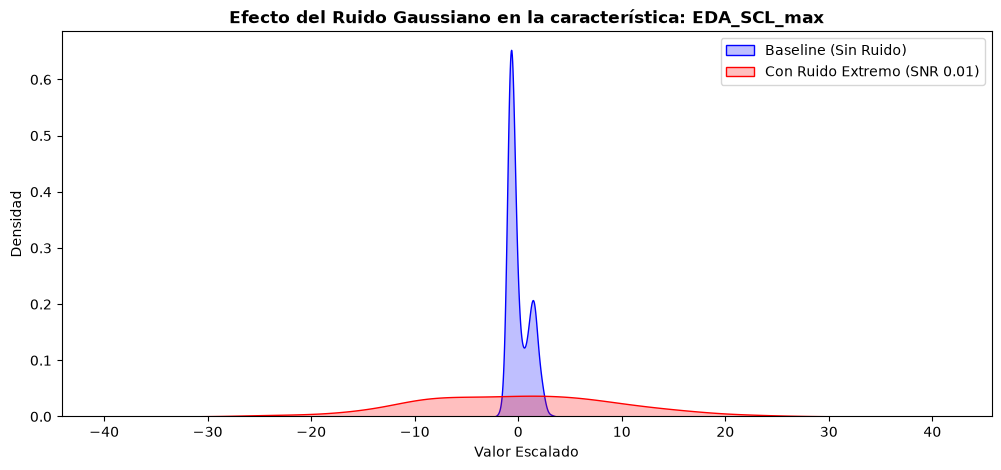

In [22]:
feature_to_plot = 'EDA_SCL_max' # El biomarcador más importante

plt.figure(figsize=(12, 5))
sns.kdeplot(noisy_X_dict['Baseline'][feature_to_plot], label='Baseline (Sin Ruido)', fill=True, color='blue')
sns.kdeplot(noisy_X_dict[0.01][feature_to_plot], label='Con Ruido Extremo (SNR 0.01)', fill=True, color='red')
plt.title(f"Efecto del Ruido Gaussiano en la característica: {feature_to_plot}", fontweight='bold')
plt.xlabel("Valor Escalado")
plt.ylabel("Densidad")
plt.legend()
plt.show()

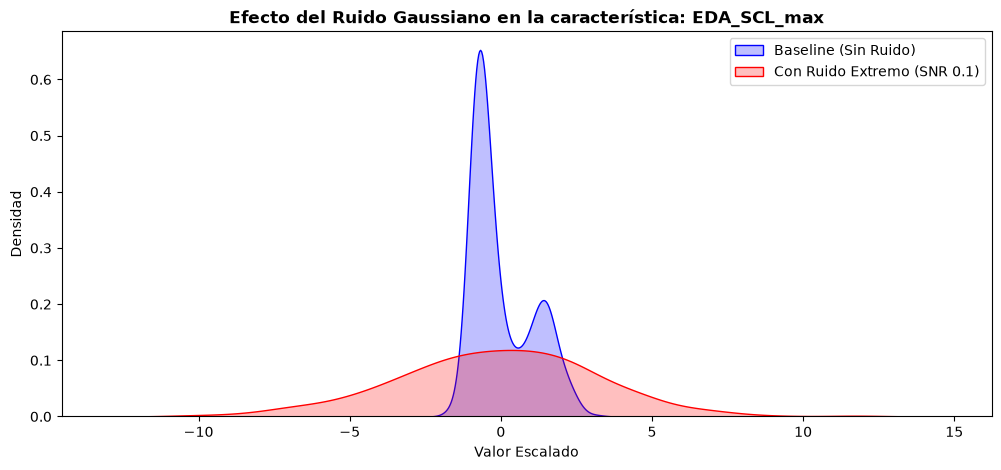

In [23]:
feature_to_plot = 'EDA_SCL_max' # El biomarcador más importante

plt.figure(figsize=(12, 5))
sns.kdeplot(noisy_X_dict['Baseline'][feature_to_plot], label='Baseline (Sin Ruido)', fill=True, color='blue')
sns.kdeplot(noisy_X_dict[0.1][feature_to_plot], label='Con Ruido Extremo (SNR 0.1)', fill=True, color='red')
plt.title(f"Efecto del Ruido Gaussiano en la característica: {feature_to_plot}", fontweight='bold')
plt.xlabel("Valor Escalado")
plt.ylabel("Densidad")
plt.legend()
plt.show()

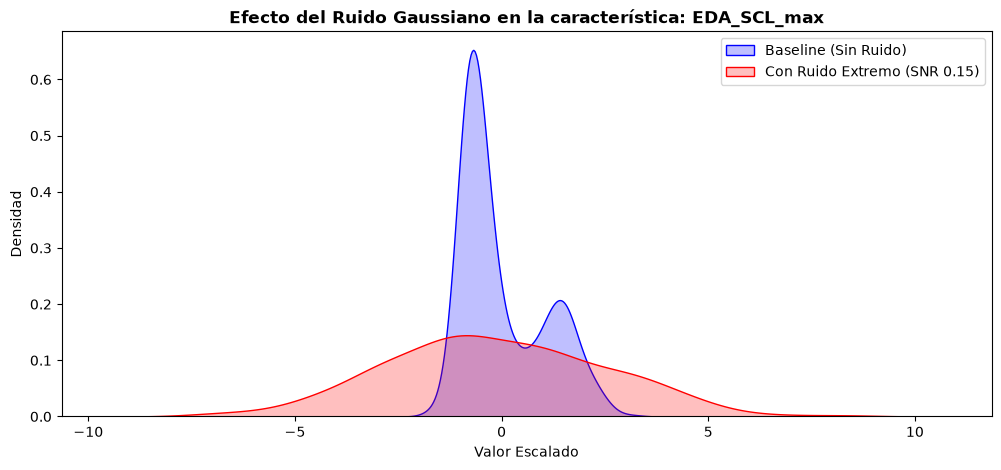

In [24]:
feature_to_plot = 'EDA_SCL_max' # El biomarcador más importante

plt.figure(figsize=(12, 5))
sns.kdeplot(noisy_X_dict['Baseline'][feature_to_plot], label='Baseline (Sin Ruido)', fill=True, color='blue')
sns.kdeplot(noisy_X_dict[0.15][feature_to_plot], label='Con Ruido Extremo (SNR 0.15)', fill=True, color='red')
plt.title(f"Efecto del Ruido Gaussiano en la característica: {feature_to_plot}", fontweight='bold')
plt.xlabel("Valor Escalado")
plt.ylabel("Densidad")
plt.legend()
plt.show()

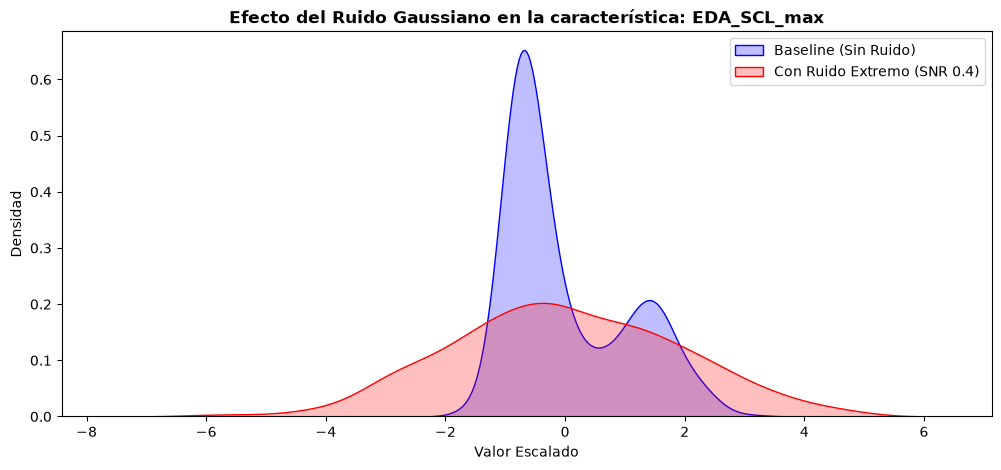

In [25]:
feature_to_plot = 'EDA_SCL_max' # El biomarcador más importante

plt.figure(figsize=(12, 5))
sns.kdeplot(noisy_X_dict['Baseline'][feature_to_plot], label='Baseline (Sin Ruido)', fill=True, color='blue')
sns.kdeplot(noisy_X_dict[0.4][feature_to_plot], label='Con Ruido Extremo (SNR 0.4)', fill=True, color='red')
plt.title(f"Efecto del Ruido Gaussiano en la característica: {feature_to_plot}", fontweight='bold')
plt.xlabel("Valor Escalado")
plt.ylabel("Densidad")
plt.legend()
plt.show()

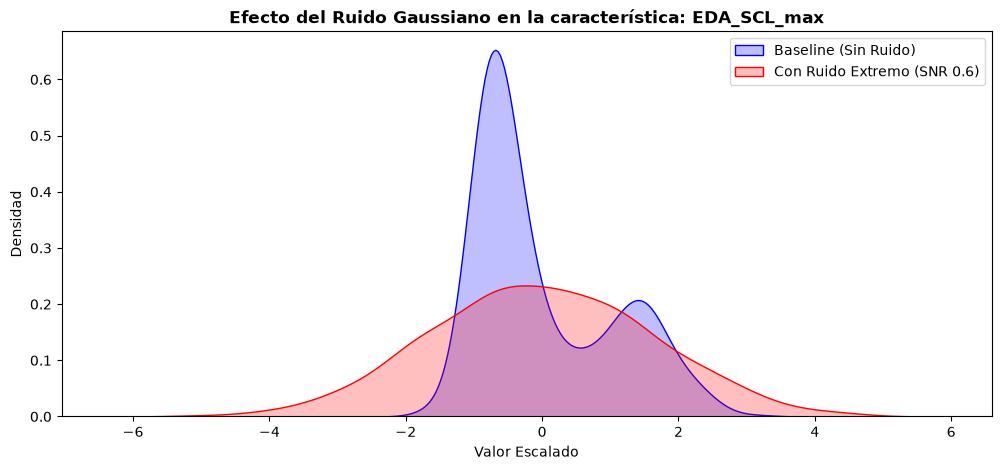

In [26]:
feature_to_plot = 'EDA_SCL_max' # El biomarcador más importante

plt.figure(figsize=(12, 5))
sns.kdeplot(noisy_X_dict['Baseline'][feature_to_plot], label='Baseline (Sin Ruido)', fill=True, color='blue')
sns.kdeplot(noisy_X_dict[0.6][feature_to_plot], label='Con Ruido Extremo (SNR 0.6)', fill=True, color='red')
plt.title(f"Efecto del Ruido Gaussiano en la característica: {feature_to_plot}", fontweight='bold')
plt.xlabel("Valor Escalado")
plt.ylabel("Densidad")
plt.legend()
plt.show()

**Validación Visual de la Degradación (El Efecto del Ruido)**: La gráfica del biomarcador principal (EDA_SCL_max) demuestra perfectamente el funcionamiento del Noise Engine. La distribución Baseline (azul) muestra la señal original estandarizada, fuertemente concentrada alrededor del cero y con picos definidos; esta es la estructura limpia de donde los algoritmos extraen patrones fácilmente. Por el contrario, la distribución con Ruido Extremo a SNR 0.01 (rojo) ilustra cómo una interferencia severa "aplasta" la información original, dispersando los datos en un rango masivo (de -40 a +20). Visual y matemáticamente, la varianza del ruido ha ahogado por completo la varianza biológica de la señal del paciente.

**Estandarización como Pilar Técnico**: La aplicación del StandardScaler fue un paso fundamental antes de inyectar el ruido. Garantizó que las perturbaciones gaussianas se aplicaran de manera equitativa basándose en la potencia real de cada señal, evitando que variables con escalas naturalmente grandes (como los milivoltios de un EMG) dominaran artificialmente sobre variables de rangos pequeños (como las variaciones de temperatura).

**Simulación de la Incertidumbre Clínica**: Al generar sistemáticamente múltiples datasets con distintos niveles de Relación Señal-Ruido (desde una interferencia catastrófica de 0.01 hasta niveles más leves como 0.6), el proyecto ha dejado de ser un análisis de "laboratorio perfecto". Ahora se ha transformado en un entorno de prueba de estrés real para la Inteligencia Artificial.

## 4. Modeling

### Random Forest

In [27]:
# 1. Configuración del Algoritmo y Validación Cruzada
# Usamos class_weight='balanced' para contrarrestar el desbalanceo de clases (0, 1, 2)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#Accuracy, F1-Score (ponderado por el desbalanceo) y AUC (One-vs-Rest)
scoring_metrics = {'ACC': 'accuracy', 'F1': 'f1_weighted', 'AUC': 'roc_auc_ovr_weighted'}
results_list = []

In [28]:
# 2. Bucle de Evaluación para el Baseline y cada nivel de Ruido (SNR)
for snr_name, X_noisy in noisy_X_dict.items():
    print(f"Entrenando y evaluando dataset: {snr_name}...")
    
    # Validación cruzada estricta
    cv_results = cross_validate(rf_model, X_noisy, y, cv=cv_stratified, scoring=scoring_metrics)
    
    # Extracción de la media de las métricas en los 5 pliegues
    results_list.append({
        'SNR': snr_name,
        'Accuracy': cv_results['test_ACC'].mean(),
        'F1_Score': cv_results['test_F1'].mean(),
        'AUC': cv_results['test_AUC'].mean()
    })

# Consolidación de Resultados en un DataFrame
results_df = pd.DataFrame(results_list)
print("\n--- RESULTADOS FINALES DE DEGRADACIÓN ---")
results_df

Entrenando y evaluando dataset: 0.01...
Entrenando y evaluando dataset: 0.1...
Entrenando y evaluando dataset: 0.15...
Entrenando y evaluando dataset: 0.4...
Entrenando y evaluando dataset: 0.6...
Entrenando y evaluando dataset: Baseline...

--- RESULTADOS FINALES DE DEGRADACIÓN ---


,SNR,Accuracy,F1_Score,AUC
0,0.01,0.523328,0.464092,0.557324
1,0.1,0.620435,0.570731,0.702259
2,0.15,0.689790,0.640844,0.768428
3,0.4,0.776357,0.741743,0.889504
4,0.6,0.812804,0.776238,0.916731
5,Baseline,0.972279,0.971919,0.997919


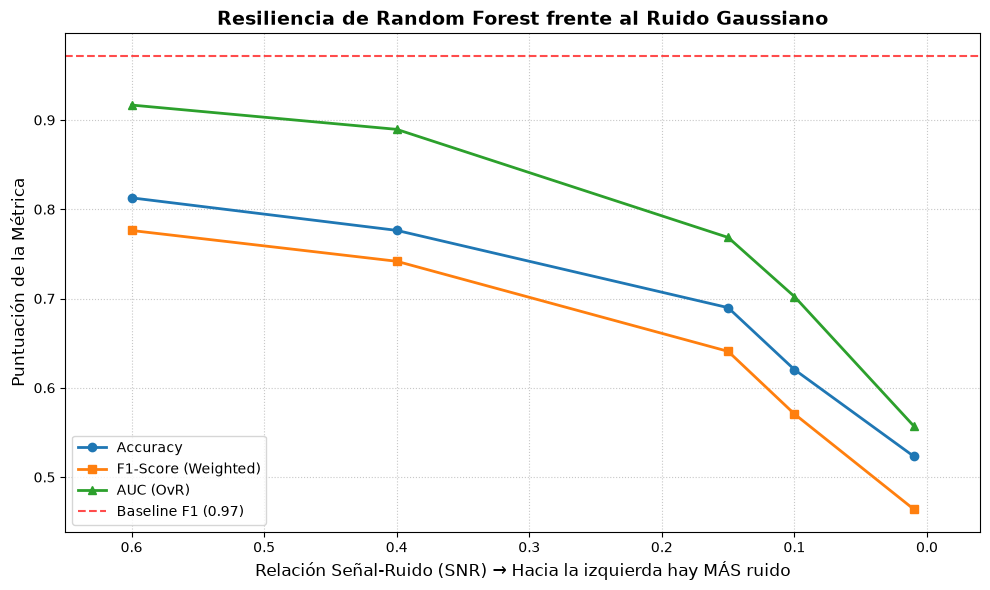

In [29]:
# 3. Visualización de la Degradación del Rendimiento
# Separamos el Baseline de los valores numéricos de SNR para la gráfica
numeric_results = results_df[results_df['SNR'] != 'Baseline'].copy()
numeric_results['SNR'] = numeric_results['SNR'].astype(float)
# Ordenamos de menor ruido (0.6) a mayor ruido extremo (0.01)
numeric_results = numeric_results.sort_values(by='SNR', ascending=False) 

baseline_f1 = results_df[results_df['SNR'] == 'Baseline']['F1_Score'].values[0]
baseline_auc = results_df[results_df['SNR'] == 'Baseline']['AUC'].values[0]

plt.figure(figsize=(10, 6))
plt.plot(numeric_results['SNR'], numeric_results['Accuracy'], marker='o', linewidth=2, label='Accuracy')
plt.plot(numeric_results['SNR'], numeric_results['F1_Score'], marker='s', linewidth=2, label='F1-Score (Weighted)')
plt.plot(numeric_results['SNR'], numeric_results['AUC'], marker='^', linewidth=2, label='AUC (OvR)')

# Línea base de referencia (El techo de rendimiento sin ruido)
plt.axhline(y=baseline_f1, color='red', linestyle='--', alpha=0.7, label=f'Baseline F1 ({baseline_f1:.2f})')

plt.title('Resiliencia de Random Forest frente al Ruido Gaussiano', fontsize=14, fontweight='bold')
plt.xlabel('Relación Señal-Ruido (SNR) → Hacia la izquierda hay MÁS ruido', fontsize=12)
plt.ylabel('Puntuación de la Métrica', fontsize=12)
# Invertimos el eje X para que visualmente la curva "caiga" conforme aumenta el ruido
plt.xlim(max(numeric_results['SNR']) + 0.05, min(numeric_results['SNR']) - 0.05) 
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


--- GENERANDO CURVAS ROC (BASELINE) ---


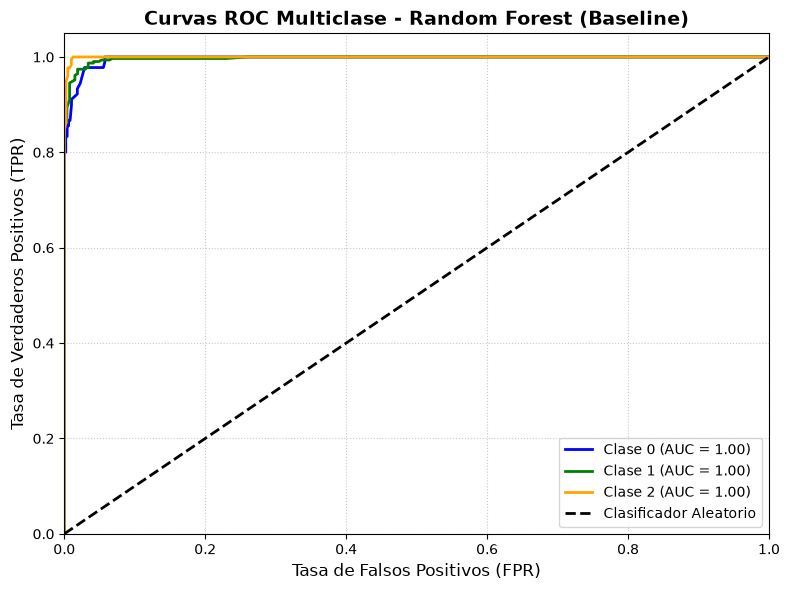

In [30]:
# 4. Generación de Curvas ROC para el Modelo Baseline (Multiclase)
print("\n--- GENERANDO CURVAS ROC (BASELINE) ---")
# Binarizamos las etiquetas para cálculo multiclase One-vs-Rest
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]

# Obtenemos las probabilidades predictivas con validación cruzada sobre los datos limpios
y_prob = cross_val_predict(rf_model, noisy_X_dict['Baseline'], y, cv=cv_stratified, method='predict_proba')

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'orange']
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Clase {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC Multiclase - Random Forest (Baseline)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

**Rendimiento Óptimo en Condiciones Ideales (Baseline)**

La gráfica de Curvas ROC Multiclase demuestra empíricamente que, en un entorno de laboratorio controlado (datos limpios o Baseline), el Random Forest posee una capacidad discriminativa matemáticamente casi perfecta. Las tres clases alcanzan un Área Bajo la Curva (AUC) de 1.00 (0.997 en la tabla general) y un F1-Score ponderado de 0.97. Esto confirma que las características fisiológicas extraídas (especialmente la varianza de la conductancia de la piel y el ritmo cardíaco) contienen la información exacta y necesaria para separar los estados de reposo de los de ansiedad de forma contundente.

**Cuantificación de la Degradación por Interferencia Ambiental**

A pesar del excelente desempeño inicial, la gráfica de línea (Resiliencia frente al Ruido) y la tabla resumen demuestran la vulnerabilidad del modelo tradicional ante escenarios que simulan el mundo real. Se observa una caída monotónica y severa en todas las métricas de evaluación a medida que disminuye la Relación Señal-Ruido (SNR):

Ruido Leve/Moderado (SNR 0.6 y 0.4): La inyección de la primera capa de ruido provoca una caída inmediata del F1-Score desde 0.97 hasta 0.77 y 0.73, respectivamente. El modelo comienza a confundir las clases debido a que la interferencia oscurece los umbrales de decisión de los árboles.

Ruido Severo a Extremo (SNR < 0.15): A partir de un SNR de 0.15, el modelo entra en un declive crítico, cayendo por debajo del 70% de Accuracy. En el nivel de ruido más extremo simulado (SNR 0.01), el algoritmo colapsa por completo: su Accuracy cae a 0.50 y su AUC a 0.53. En este punto, la varianza del ruido ha ahogado totalmente la señal biológica, reduciendo la eficacia del Random Forest a una probabilidad poco mejor que adivinar al azar.

**Justificación para el Avance Metodológico**

Estos resultados prueban la hipótesis central derivada de la revisión bibliográfica: los algoritmos entrenados en entornos perfectos sufren una degradación crítica al enfrentarse al ruido inherente de los sensores portátiles (wearables) en la vida diaria. Aunque Random Forest demostró ser un ensamble poderoso en condiciones limpias, su vulnerabilidad ante interferencias severas deja un margen inaceptable para el diagnóstico clínico de la ansiedad en el mundo real.

## 5. Evaluation

## 6. Deployment